# Notebook 04: Modelado
Se eligió Regresión Logística como modelo baseline. Con ~475 registros y pocas variables, es un modelo simple, rápido de entrenar y, sobre todo, fácil de interpretar: cada coeficiente indica cómo cambia la probabilidad de un ECG anormal por cada variable, lo cual es valioso en un caso de uso clínico donde las decisiones deben poder explicarse y auditarse. Se usa 'class_weight='balanced'' para compensar el desbalance de clases, y se estandarizan las variables numéricas antes de entrenar, ya que Regresión Logística es sensible a diferencias de escala entre ellas.

Se descartaron Random Forest y XGBoost como modelo principal: si bien pueden ofrecer mejor desempeño puro, son menos interpretables y más complejos de justificar como modelo base para un dataset de este tamaño, cuando el objetivo de esta sección no es maximizar accuracy sino razonar sobre los datos y las variables usadas.

## 1. Preparación de las características
En esta sección se escogen las variables que se van a incluir en el modelo y se preparan las variables categóricas. Las variables a usar son:
- Edad
- sexo (necesita preparación)
- IMC
- frecuencia_cardiaca
- std_mV

In [1]:
import os
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

sys.path.append(os.path.dirname(os.getcwd()))

from src import (
    COLUMNS,
    prepare_dataset_for_modeling,
    load_patient_dataset,
    prepare_features,
    train_and_evaluate,
    plot_confusion_matrix,
    plot_error_by_quantile_bar
)

In [2]:
df_clean = load_patient_dataset('salva-health-data', 'pacientes_features.csv')
df_raw = load_patient_dataset('salva-health-data', 'pacientes.csv')

print(f"Dataset limpio: {len(df_clean)} registros")
print(f"Dataset crudo: {len(df_raw)} registros")
df_clean.head()

Dataset limpio: 475 registros
Dataset crudo: 515 registros


,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta,n_samples,duration_seg,sampling_rate_hz,std_mV,range_mV,imc
0,P0305,82.0,M,69.8,168.0,2023-10-04,69.4,II,250,Normal,2500,9.996,250,0.1621,1.2189,24.730726
1,P0500,58.0,M,70.9,178.9,2023-04-23,79.2,II,250,Normal,2500,9.996,250,0.1685,1.2394,22.152643
2,P0442,49.0,M,84.2,173.1,2023-01-25,72.7,II,250,Normal,2500,9.996,250,0.1686,1.2379,28.100753
3,P0154,39.0,F,80.5,156.4,2023-06-24,87.0,II,250,Anormal,2500,9.996,250,0.1775,1.2779,32.909583
4,P0479,22.0,F,78.7,165.5,2023-01-28,77.8,II,250,Normal,2500,9.996,250,0.1736,1.2321,28.732852


In [3]:
model_features = [
    COLUMNS['age'],
    COLUMNS['sex'],
    COLUMNS['imc'],
    COLUMNS['heart_rate'],
    COLUMNS['std_mv'],
]

df_clean_prepared = prepare_dataset_for_modeling(df_clean, is_raw=False)
df_raw_prepared = prepare_dataset_for_modeling(df_raw, is_raw=True)

print(f"Dataset limpio preparado: {len(df_clean_prepared)} registros, {len(df_clean_prepared.columns)} columnas")
print(f"Dataset crudo preparado: {len(df_raw_prepared)} registros, {len(df_raw_prepared.columns)} columnas")

print(f"\nColumnas en limpio: {df_clean_prepared.columns.tolist()}")
print(f"Columnas en crudo: {df_raw_prepared.columns.tolist()}")

Dataset limpio preparado: 475 registros, 16 columnas
Dataset crudo preparado: 515 registros, 16 columnas

Columnas en limpio: ['id_paciente', 'edad_paciente', 'sexo', 'peso_kg', 'altura_cm', 'fecha_registro', 'frecuencia_cardiaca_media_bpm', 'derivacion_ecg', 'frecuencia_muestreo_hz', 'etiqueta', 'n_samples', 'duration_seg', 'sampling_rate_hz', 'std_mV', 'range_mV', 'imc']
Columnas en crudo: ['id_paciente', 'edad_paciente', 'sexo', 'peso_kg', 'altura_cm', 'fecha_registro', 'frecuencia_cardiaca_media_bpm', 'derivacion_ecg', 'frecuencia_muestreo_hz', 'etiqueta', 'imc', 'n_samples', 'duration_seg', 'sampling_rate_hz', 'std_mV', 'range_mV']


In [4]:
X_clean, Y_clean = prepare_features(
    df_clean_prepared, 
    model_features, 
    COLUMNS['sex'], 
    COLUMNS['label']
)

print(f"X_clean shape: {X_clean.shape}")
print(f"Y_clean shape: {Y_clean.shape}")
print(f"Features limpias: {X_clean.columns.tolist()}")

X_raw, Y_raw = prepare_features(
    df_raw_prepared, 
    model_features, 
    COLUMNS['sex'], 
    COLUMNS['label']
)

print(f"\nX_raw shape: {X_raw.shape}")
print(f"Y_raw shape: {Y_raw.shape}")
print(f"Features crudas: {X_raw.columns.tolist()}")

X_clean shape: (475, 5)
Y_clean shape: (475,)
Features limpias: ['edad_paciente', 'imc', 'frecuencia_cardiaca_media_bpm', 'std_mV', 'sexo_M']

X_raw shape: (495, 5)
Y_raw shape: (495,)
Features crudas: ['edad_paciente', 'imc', 'frecuencia_cardiaca_media_bpm', 'std_mV', 'sexo_M']


## 2. Modelo Regresión Logística

In [5]:
model_clean = train_and_evaluate(X_clean, Y_clean)
model_raw = train_and_evaluate(X_raw, Y_raw)

comparison = pd.DataFrame({
    'Limpio': model_clean['metrics_test'],
    'Crudo': model_raw['metrics_test'],
}).round(3)


print(comparison)

           Limpio  Crudo
precision   0.719  0.800
recall      0.793  0.800
f1          0.754  0.800
auc_roc     0.852  0.855


In [6]:
duplicados_raw = df_raw_prepared[df_raw_prepared.duplicated(subset=COLUMNS['patient_id'], keep=False)]
print(f"Filas con id_paciente duplicado en el dataset crudo: {len(duplicados_raw)}")

train_ids = set(X_raw.loc[model_raw['x_test'].index].index) 
ids_train = df_raw_prepared.loc[X_raw.index.difference(model_raw['x_test'].index), COLUMNS['patient_id']]
ids_test = df_raw_prepared.loc[model_raw['x_test'].index, COLUMNS['patient_id']]
fuga = set(ids_train) & set(ids_test)
print(f"Pacientes presentes tanto en train como en test (crudo): {len(fuga)}")

Filas con id_paciente duplicado en el dataset crudo: 30
Pacientes presentes tanto en train como en test (crudo): 3


In [7]:
duplicados_clean = df_clean_prepared[df_clean_prepared.duplicated(subset=COLUMNS['patient_id'], keep=False)]
print(f"Filas con id_paciente duplicado en el dataset limpio: {len(duplicados_clean)}")
print(f"IDs únicos en limpio: {df_clean_prepared[COLUMNS['patient_id']].nunique()} de {len(df_clean_prepared)} registros")

Filas con id_paciente duplicado en el dataset limpio: 0
IDs únicos en limpio: 475 de 475 registros


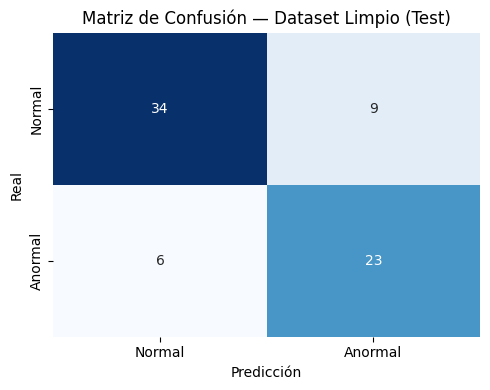

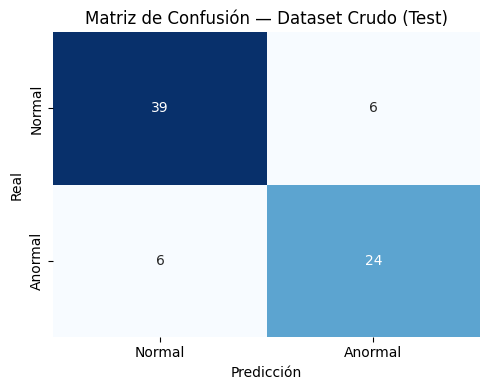

In [8]:
plot_confusion_matrix(
    model_clean['y_test'], 
    model_clean['pred_test'], 
    title='Matriz de Confusión — Dataset Limpio (Test)'
)
plt.show()

plot_confusion_matrix(
    model_raw['y_test'], 
    model_raw['pred_test'], 
    title='Matriz de Confusión — Dataset Crudo (Test)'
)
plt.show()


Error promedio por cuartil de FRECUENCIA CARDÍACA
quantil  error_promedio
     Q1        0.257317
     Q2        0.353443
     Q3        0.459328
     Q4        0.152068

Error promedio por cuartil de EDAD
quantil  error_promedio
     Q1        0.282392
     Q2        0.350449
     Q3        0.283677
     Q4        0.303079

Error promedio por cuartil de IMC
quantil  error_promedio
     Q1        0.298240
     Q2        0.322036
     Q3        0.348573
     Q4        0.253308


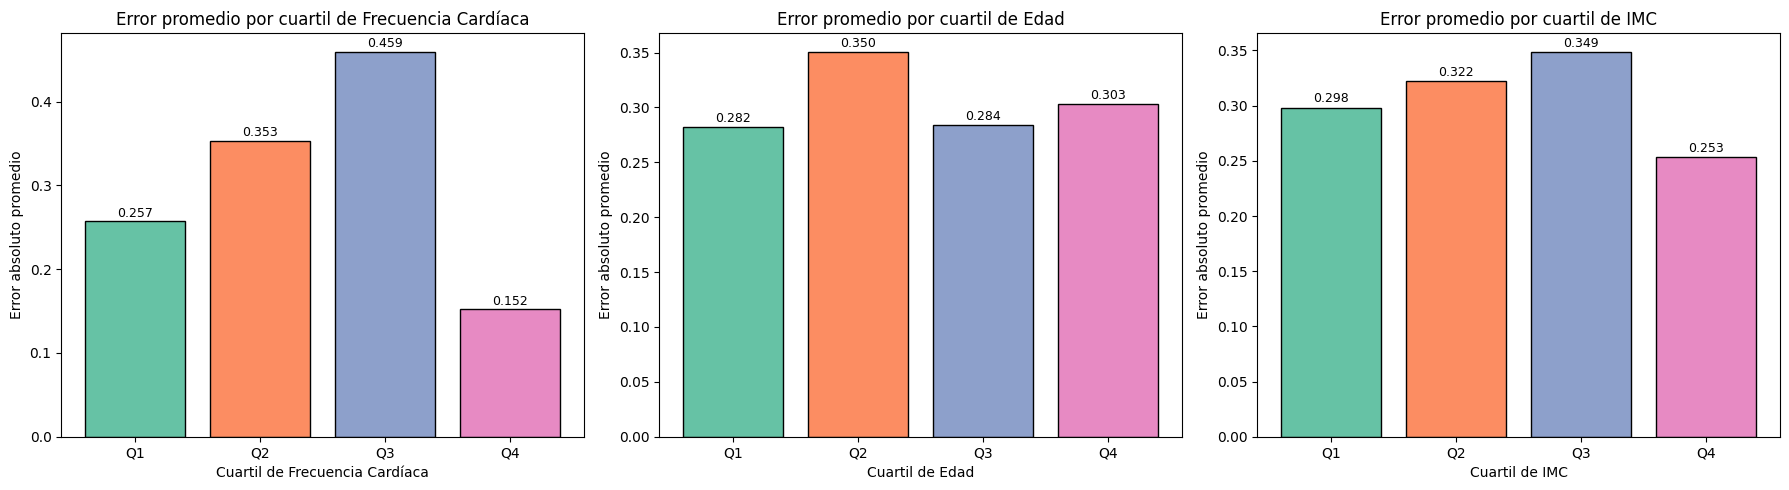

In [9]:
variables = [
    (COLUMNS['heart_rate'], 'Frecuencia Cardíaca'),
    (COLUMNS['age'], 'Edad'),
    (COLUMNS['imc'], 'IMC'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, name) in enumerate(variables):
    var_test = df_clean_prepared.loc[model_clean['x_test'].index, col]
    ax, _ = plot_error_by_quantile_bar(
        y_true=model_clean['y_test'],
        proba_pred=model_clean['proba_test'],
        variable=var_test,
        variable_name=name,
        n_quantiles=4,
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

El error del modelo fue consistente en la mayoría de las variables, sin sesgos significativos. En frecuencia cardíaca, el error fue mayor en los cuartiles intermedios y menor en los extremos, lo cual es esperable: los casos con valores muy bajos o muy altos son clínicamente más definidos y fáciles de clasificar, mientras que los valores intermedios corresponden a diagnósticos más inciertos. En edad e IMC, el error se mantuvo estable entre cuartiles indicando que el modelo no presenta sesgos relevantes por estos factores y generaliza adecuadamente en toda la población.

In [10]:
coef_df = pd.DataFrame({
    'Variable': X_clean.columns,
    'Coeficiente': model_clean['modelo_final'].coef_[0]
})

coef_df['Importancia'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values('Importancia', ascending=False)

# Coeficiente positivo, mayor probabilidad de Anormal
print(coef_df[['Variable', 'Coeficiente']].to_string(index=False))

                     Variable  Coeficiente
frecuencia_cardiaca_media_bpm     1.215883
                       std_mV     0.882753
                edad_paciente     0.286760
                          imc    -0.172010
                       sexo_M    -0.098889


Los coeficientes de la regresión logística confirman que la frecuencia cardíaca es el predictor más relevante (coeficiente 1.216), seguida por la variabilidad de la señal ECG (0.883) y la edad (0.287). La frecuencia cardíaca elevada es un marcador clínico bien establecido de alteraciones cardíacas. La edad, aunque con menor peso, mantiene un efecto positivo y moderado. Por el contrario, el IMC (-0.172) y el sexo masculino (-0.099) presentan coeficientes cercanos a cero, confirma los hallazgos del análisis exploratorio, donde no se observaron diferencias significativas entre grupos. 

**Comparación datasets** 
El dataset crudo mostró métricas de test ligeramente superiores al limpio (F1 0.800 vs. 0.754, AUC-ROC 0.855 vs. 0.852). Se confirmó que el dataset limpio no tiene ningún id_paciente duplicado (475 ids únicos en 475 registros), mientras que el crudo sí (30 duplicados), de las cuales 3 quedaron repartidas entre entrenamiento y prueba. Esto afecta el desempeño del crudo, dado que afecta solo aproximadamente 4% del test, tampoco explica toda la diferencia observada. Este resultado no significa que la limpieza fue innecesaria, evidencia lo contrario, un riesgo concreto de trabajar con datos sin limpiar, donde los duplicados pueden filtrar información entre entrenamiento y prueba sin que sea evidente en las métricas agregadas. 


**Conclusiones sobre el modelo**
Se construyó un modelo baseline de regresión logística con class_weight='balanced' utilizando cinco variables clínicas y de señal. El modelo alcanzó un AUC-ROC de 0.852 en el conjunto de prueba, con un F1-score de 0.754. La frecuencia cardíaca resultó ser el predictor más relevante, seguida por la variabilidad de la señal ECG y la edad, mientras que el IMC y el sexo mostraron contribuciones poco significativas. El análisis de error por cuartiles no evidenció sesgos significativos por edad, IMC o sexo, aunque el modelo presentó mayor incertidumbre en rangos intermedios de frecuencia cardíaca.